# Análise de resultados

Este notebook será responsável por analisar os dados obtidos com a execução dos algoritmos de ordenação.

## Preparação dos dados

Para iniciar a análise, os dados de benchmark serão carregados para um `Data Frame (pandas)` com os dados totais. Em seguida, carregar cada cenário de testes em `Data Frames` específicos.

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set_theme(style="whitegrid")

# 1. Carregar os dados
url = "https://github.com/olucasaguiar/projeto-metodos-de-ordenacao/raw/main/results/benchmarks.csv"
df = pd.read_csv(url, usecols=["Algorithm", "Sample", "Size", "Iteration", "Duration (ns)"])

# Transformacao dos dados
df["duration_ms"] = df["Duration (ns)"] / 1e6
df["duration_s"] = df["Duration (ns)"] / 1e9

<Figure size 2400x600 with 0 Axes>

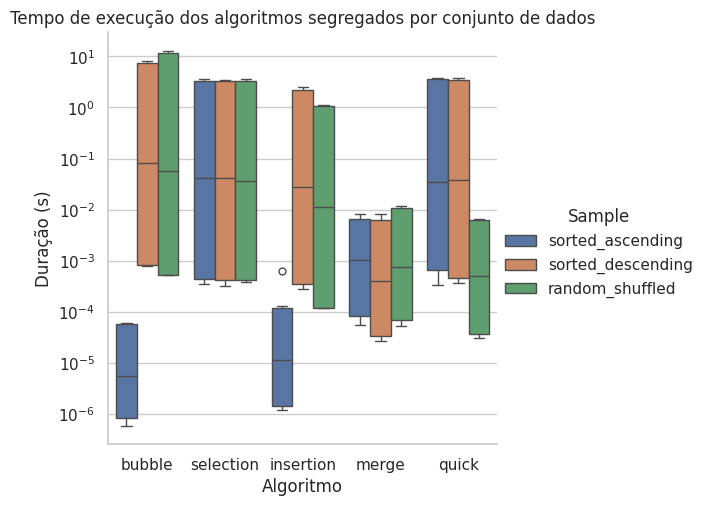

In [116]:
# Análise por cenário de teste
def plot(
    data: pd.DataFrame,
    title: str,
    x: str,
    x_label,
    y: str,
    y_label: str,
    hue: str | None = None,
    kind: str = "box",
    use_log_scale: bool = False,
    figsize=(24, 6),
):
    plt.figure(figsize=figsize)
    sns.catplot(data=data, x=x, y=y, hue=hue, kind=kind)
    plt.title(title)
    if use_log_scale:
        plt.yscale("log")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


plot(
    data=df,
    title="Tempo de execução dos algoritmos segregados por conjunto de dados",
    x="Algorithm",
    x_label="Algoritmo",
    y="duration_s",
    y_label="Duração (s)",
    hue="Sample",
    kind="box",
    use_log_scale=True,
)

## Análise vetor em ordem crescente

Iniciando a análise com o primeiro conjunto de `Data Frames`, contendo dados de já ordenados. Nesse cenário, todos os algoritmos foram executados com o vetor previamente ordenado, assim, podemos considerar este cenário como "melhor caso".

O teste irá demonstrar como os vetores se comportam se a estrutura de dados que será ordenada já se encontra em sua versão final, ou seja, em ordem crescente.

<Figure size 2400x600 with 0 Axes>

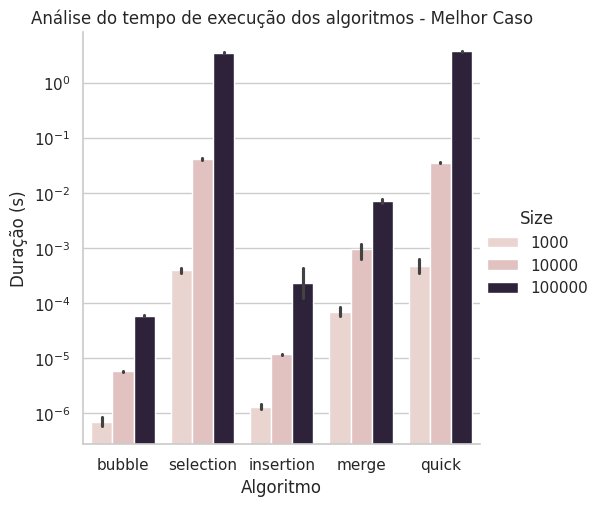

In [117]:
random_shuffled_df = df[df["Sample"] == "sorted_ascending"]
plot(
    data=random_shuffled_df,
    title="Análise do tempo de execução dos algoritmos - Melhor Caso",
    x="Algorithm",
    x_label="Algoritmo",
    y="duration_s",
    y_label="Duração (s)",
    hue="Size",
    kind="bar",
    use_log_scale=True,
)

## Análise vetor em ordem decrescente

Agora seguimos para o segundo conjunto contendo dados de já ordenados, porém em ordem decrescente. Podemos considerar esse conjunto como sendo o pior caso, já que todos os elementos precisam trocados de posição para chegar ao resultado esperado.

A visualização dos dados seguirá a mesma da representação anterior, os algoritmos distribuídos em eixo horizontal (x) e o tempo em eixo vertical (y).

<Figure size 2400x600 with 0 Axes>

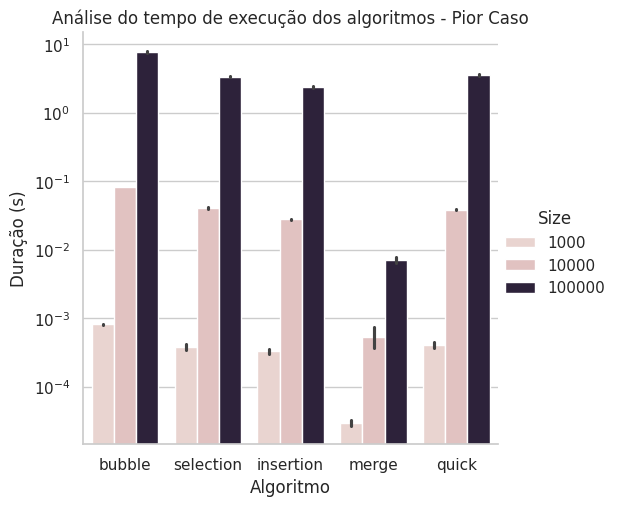

In [118]:
random_shuffled_df = df[df["Sample"] == "sorted_descending"]
plot(
    data=random_shuffled_df,
    title="Análise do tempo de execução dos algoritmos - Pior Caso",
    x="Algorithm",
    x_label="Algoritmo",
    y="duration_s",
    y_label="Duração (s)",
    hue="Size",
    kind="bar",
    use_log_scale=True,
)

## Análise vetor embaralhado

A última análise será feita no conjunto de dados embaralhados. Como os dados foram distribuídos de forma aleatória, podemos considerar que esse conjunto representa um caso médio, já que o número de permutações pode ser variável entre O(n) e O(n²).

A representação dos dados segue o mesmo formato de visualização dos cenários anteriores.

<Figure size 2400x600 with 0 Axes>

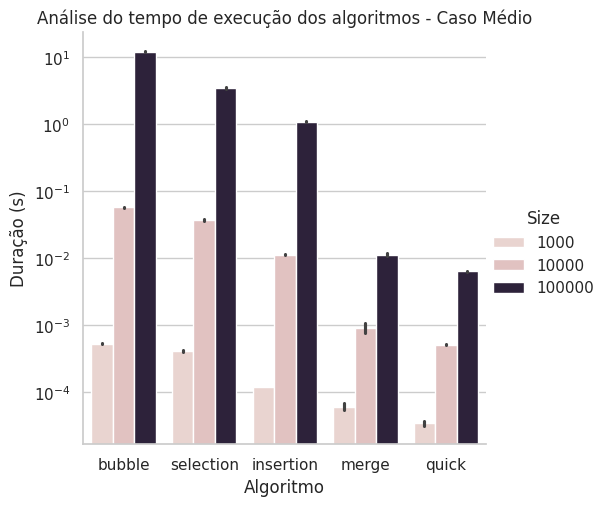

In [121]:
random_shuffled_df = df[df["Sample"] == "random_shuffled"]

plot(
    data=random_shuffled_df,
    title="Análise do tempo de execução dos algoritmos - Caso Médio",
    x="Algorithm",
    x_label="Algoritmo",
    y="duration_s",
    y_label="Duração (s)",
    hue="Size",
    kind="bar",
    use_log_scale=True,
)

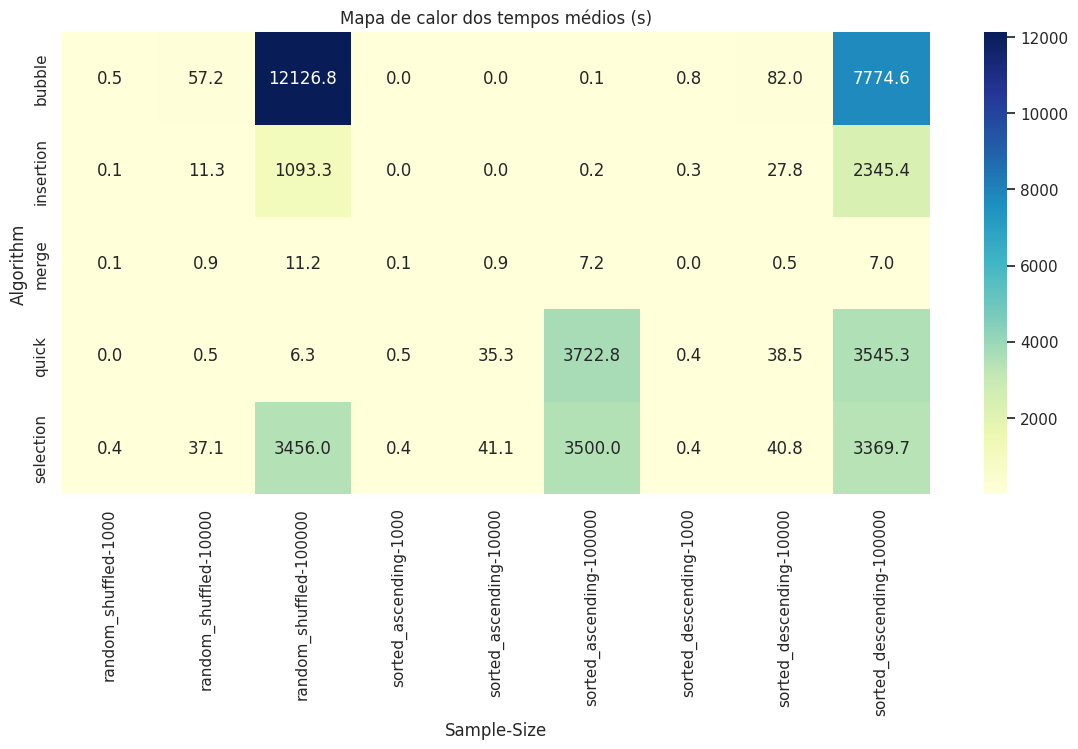

In [ ]:
# Mapa de calor
mean_df = df.groupby(["Algorithm", "Sample", "Size"])["duration_ms"].mean().reset_index()

pivot = df.pivot_table(values="duration_ms", index="Algorithm", columns=["Sample", "Size"])
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Mapa de calor dos tempos médios (s)")
plt.show()